# 反応器の単通転化率(~38%)と選択率(~82%)は理論的必然か — 厳密検証 (Catofin)

**問い**: BO best (trial #227, **Catofin型 浅床・多基並列**) の反応器は **単通転化率 X≈38%・選択率 S≈82%**。
これは熱力学・反応速度論からの構造的挙動か、それともシミュレータの不具合か。

**結論(本notebookで厳密に示す)**:

| 指標 | 値 | 性質 | 根拠 |
|---|---|---|---|
| 単通転化率 X | ~38% | **HGM補償 + 床体積で決まる**(純断熱平衡より高い) | HGM 等価熱補償が床温を $T_{in}-\Delta T_{max}$(=608°C)以上に維持 → 断熱冷却による平衡頭打ちを回避。転化率は床体積($L_{bed},N_{online}$)で伸びる |
| 選択率 S | ~82% | **経済最適**(物理上限ではない) | 速度比 $k_1/(k_1+k_2)$ + 触媒失活で決まる。降温/短サイクルで↑可だが生産量↓/反応器数↑ |
| 総収率 | ~82% ≈ S | リサイクルで総括転化率~99% | 収率天井=選択率の運転値 |

**radial 時代との本質的な違い**:
- radial(断熱床)では「転化率は断熱平衡(~28%)で頭打ち、**体積を増やしても無効**」だった。
- Catofin は **HGM 等価熱補償**で床温を維持するため、**転化率は平衡頭打ちでなく床体積でスケールする**(§4 で実証)。
  代わりに律速するのは「HGM がどれだけ床温を保てるか($\Delta T_{max}$)」と「選択率とのトレードオフ」。

> 反応器(`units/reactors/catofin.py`, 物理は `swing.py` を per-vessel 流用)は純 Python (scipy ODE)。HYSYS 不要。


In [1]:
import os, sys, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from units.reactors.swing import (
    DesignVars as AxialDesign, FeedStream, FixedParams, simulate_swing_reactor_system,
    _ode_axial, calc_a, calc_rate_constants, _COMPS,
)
from units.reactors.catofin import CatofinDesignVars, simulate_catofin_reactor_system
from src.thermo import PDHThermo
from src.kinetics import PDHKinetics
from src.config import THERMO_DATA, PDHConfig, R, T0

th  = PDHThermo(); kin = PDHKinetics(); cfg = PDHConfig()

# ---- BO best #227 (Catofin) の反応器入口 (reactor_inlet) ----
# H2 は PSA, C2 は Dist2 で除去済 → 入口は C3H8(70%) + C3H6 リサイクル(30%) の C3 主体。
A0, B0 = 3811.6, 1635.7
F_IN = {'A': A0, 'B': B0, 'C': 0.0, 'D': 0.0, 'E': 0.0, 'F': 0.0}
T_IN = 931.13                     # K (= 658 degC, 予熱炉出口 = 設計変数)
P    = 50000.0                    # Pa (0.5 bar)
# Catofin 設計点 (#227)
CAT  = dict(T_in=T_IN, t_cyc=13.99, D=6.771, L_bed=0.956, N_online=24, d_p=0.003156)
DT_MAX = float(os.environ.get('PDH_CATOFIN_DTMAX', '50'))   # HGM が許す床温降下 [K]

fixed = FixedParams()
feed  = FeedStream(F_in=F_IN, T_feed=305.03, P_in=P)

def run_cat(**kw):
    d = dict(CAT); d.update(kw)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        r = simulate_catofin_reactor_system(CatofinDesignVars(**d), feed)
    e = r.equipment
    return dict(X=r.performance.Conversion, S=r.performance.Selectivity,
                Tout=r.effluent.T_out_avg-273.15, dP=e.dP_over_P_actual*100,
                pen=e.penalty_reason or 'OK', Ntot=e.N_reactors_total,
                Wcat=e.Catalyst_Weight_Total/1000, Q=r.effluent.Q_preheat)

print(f'反応器入口: C3H8={A0:.0f}  C3H6(recycle)={B0:.0f} kmol/h  (C3H6分率 {B0/(A0+B0)*100:.0f}%)')
print(f'T_in={T_IN-273.15:.0f}C  P={P/1e5:.2f}bar  HGM floor=T_in-DTmax={T_IN-273.15-DT_MAX:.0f}C')
print(f'Arrhenius: Ea1={cfg.rxn1.Ea1/1e3:.1f}  Ea2={cfg.rxn2.Ea2/1e3:.1f}  Ea3={cfg.rxn3.Ea3/1e3:.1f} kJ/mol')


反応器入口: C3H8=3812  C3H6(recycle)=1636 kmol/h  (C3H6分率 30%)
T_in=658C  P=0.50bar  HGM floor=T_in-DTmax=608C
Arrhenius: Ea1=34.6  Ea2=137.3  Ea3=154.5 kJ/mol


## §1. 反応ネットワークと速度式 (反応器形式に依らない)

コンテスト要項 §3-2 の3反応:

$$r_1:\ \mathrm{C_3H_8 \rightleftharpoons C_3H_6 + H_2}\ (\text{脱水素・所望・可逆}),\quad
  r_2:\ \mathrm{C_3H_8 \rightarrow C_2H_4 + CH_4}\ (\text{クラッキング・不可逆}),\quad
  r_3:\ \mathrm{C_2H_4 + H_2 \rightarrow C_2H_6}$$

$$r_1 = a\,k_1\,\frac{P_A - P_B P_C / K_{eq}}{1 + P_B/K_B},\qquad r_2 = k_2\,P_A,\qquad r_3 = k_3\,P_D P_C$$

- **活性係数 $a\in[0,1]$ は $r_1$ のみ**(失活は脱水素だけ止め、クラッキングは止めない)。
- $r_1$ は**可逆**、$r_2$ は**不可逆**($P_A$ 比例)。**$E_{a2}=137.3\gg E_{a1}=34.6$ kJ/mol** → 昇温で $k_2$ が急増。
- 新鮮触媒・生成物ゼロ極限の**微分選択率上限** $S_{\max}=k_1/(k_1+k_2)$(温度のみの関数)。


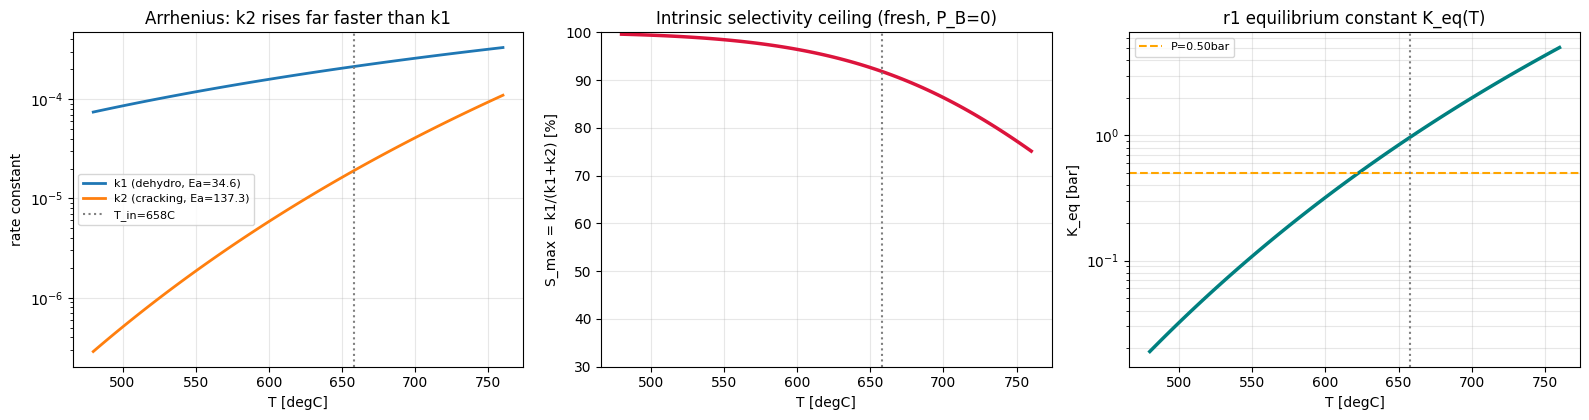

S_max=k1/(k1+k2): 520C->99%  600C->96%  658C->92%  700C->86%  750C->77%
→ 昇温で intrinsic 選択率天井が低下 (Ea2>>Ea1)。設計点 658C 近傍が S~82% の根拠。


In [2]:
Tc = np.linspace(480, 760, 80); Tk = Tc + 273.15
k1 = np.array([kin._k1(t) for t in Tk]); k2 = np.array([kin._k2(t) for t in Tk])
Keq = np.array([th.calc_keq(t) for t in Tk]); Smax = k1/(k1+k2)*100

fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
ax[0].semilogy(Tc, k1, label='k1 (dehydro, Ea=34.6)', lw=2)
ax[0].semilogy(Tc, k2, label='k2 (cracking, Ea=137.3)', lw=2)
ax[0].axvline(T_IN-273.15, color='gray', ls=':', label=f'T_in={T_IN-273.15:.0f}C')
ax[0].set_xlabel('T [degC]'); ax[0].set_ylabel('rate constant'); ax[0].legend(fontsize=8)
ax[0].set_title('Arrhenius: k2 rises far faster than k1'); ax[0].grid(True, alpha=0.3)
ax[1].plot(Tc, Smax, color='crimson', lw=2.5); ax[1].axvline(T_IN-273.15, color='gray', ls=':')
ax[1].set_xlabel('T [degC]'); ax[1].set_ylabel('S_max = k1/(k1+k2) [%]')
ax[1].set_title('Intrinsic selectivity ceiling (fresh, P_B=0)'); ax[1].grid(True, alpha=0.3); ax[1].set_ylim(30,100)
ax[2].semilogy(Tc, Keq/1e5, color='teal', lw=2.5); ax[2].axhline(P/1e5, color='orange', ls='--', label=f'P={P/1e5:.2f}bar')
ax[2].axvline(T_IN-273.15, color='gray', ls=':'); ax[2].set_xlabel('T [degC]'); ax[2].set_ylabel('K_eq [bar]')
ax[2].set_title('r1 equilibrium constant K_eq(T)'); ax[2].legend(fontsize=8); ax[2].grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()
print('S_max=k1/(k1+k2): ' + '  '.join(
    f'{t}C->{kin._k1(t+273.15)/(kin._k1(t+273.15)+kin._k2(t+273.15))*100:.0f}%' for t in [520,600,658,700,750]))
print('→ 昇温で intrinsic 選択率天井が低下 (Ea2>>Ea1)。設計点 658C 近傍が S~82% の根拠。')


## §2. 純断熱の転化率天井 vs **Catofin HGM 補償**

PDH は強吸熱($\Delta H_{r1}\approx+124$ kJ/mol)。**純断熱**ではガスが流れ方向に自己冷却して
$r_1$ がその場の平衡で止まり、**転化率が頭打ち**になる(radial/軸流断熱床の問題、`reactor_pressure_drop_*` 参照)。

**Catofin は HGM 等価熱補償**(再生蓄熱/酸化還元の熱)で床温を $T_{in}-\Delta T_{max}$(=608°C)以上に維持する。
床が冷えないので $K_{eq}$ が保たれ、**転化率は平衡頭打ちにならず床体積で伸びる**。
下で「純断熱(直接 ODE, HGM 無)」と「Catofin(HGM 有, 床体積=$L_{bed}$ 掃引)」を比較する。


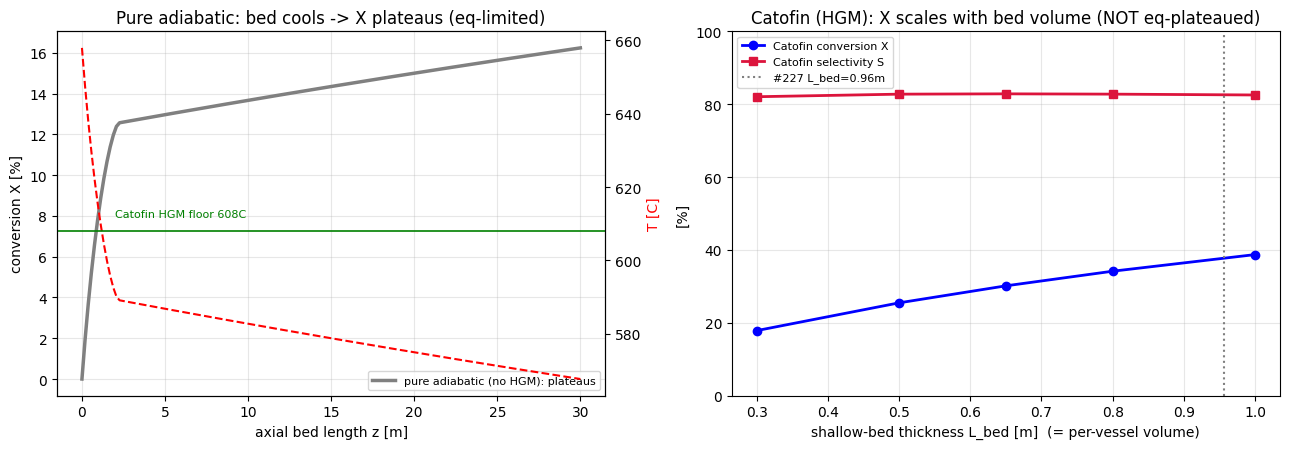

純断熱(HGM無, 直接ODE): z=30m で X=16.2%, T=568C  → 冷えて平衡頭打ち
Catofin(HGM有) L_bed 掃引: 0.3m->X=18%  0.5m->X=25%  0.65m->X=30%  0.8m->X=34%  1.0m->X=39%
  → HGM が床温を 608C 以上に維持 → 転化率は床体積でスケール (#227: X=37.8%)
  S は床体積でほぼ不変 (82-83%) = 選択率は速度論/温度で決まり体積に依らない


In [3]:
# (1) 純断熱: swing 直接 ODE (HGM floor 無し) を深い床まで積分 → 平衡頭打ちを見る。
#     大粒径(20mm)+大断面で ΔP を無視できる条件にし、断熱冷却の効果だけを分離する。
a0 = calc_a(0.0, T_IN, P); D_demo = CAT['D']; A_cross = math.pi/4*D_demo**2
_eps, _eps_bed, _phi, _dp_demo, _Np = 0.5, 0.40, 0.9, 0.020, 24
F0 = np.array([F_IN[c]*1000.0/3600.0 for c in _COMPS])
y0 = np.concatenate([F0, [T_IN], [P]])      # 状態 = [F(6), T, P]
sol = solve_ivp(lambda z, y: _ode_axial(z, y, a0, A_cross, _eps, _eps_bed, _dp_demo, _phi, _Np),
                (0, 30.0), y0, method='Radau', rtol=1e-6, atol=1e-9, dense_output=True)
zz = np.linspace(0, 30, 160)
Xad, Tad = [], []
for z in zz:
    y = sol.sol(z); F = np.maximum(y[:6], 0.0)*3600/1000
    Xad.append((A0 - F[0])/A0*100); Tad.append(y[6]-273.15)
Xad = np.array(Xad); Tad = np.array(Tad)

# (2) Catofin (HGM 有): L_bed (床体積) を掃引 → 転化率がスケール
lbs = [0.3, 0.5, 0.65, 0.8, 1.0]
Xcat = [run_cat(L_bed=lb)['X'] for lb in lbs]
Scat = [run_cat(L_bed=lb)['S'] for lb in lbs]
base = run_cat()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].plot(zz, Xad, color='gray', lw=2.5, label='pure adiabatic (no HGM): plateaus')
ax[0].plot(zz, Tad/ max(Tad)*max(Xad), ls=':', color='gray', alpha=0)  # spacer
axT = ax[0].twinx(); axT.plot(zz, Tad, color='red', lw=1.5, ls='--', label='T (adiabatic) [C]')
axT.axhline(T_IN-273.15-DT_MAX, color='green', ls='-', lw=1.2)
axT.text(2, T_IN-273.15-DT_MAX+4, f'Catofin HGM floor {T_IN-273.15-DT_MAX:.0f}C', color='green', fontsize=8)
ax[0].set_xlabel('axial bed length z [m]'); ax[0].set_ylabel('conversion X [%]')
axT.set_ylabel('T [C]', color='red'); ax[0].set_title('Pure adiabatic: bed cools -> X plateaus (eq-limited)')
ax[0].legend(loc='lower right', fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(lbs, Xcat, 'o-', color='blue', lw=2, label='Catofin conversion X')
ax[1].plot(lbs, Scat, 's-', color='crimson', lw=2, label='Catofin selectivity S')
ax[1].axvline(CAT['L_bed'], color='gray', ls=':', label=f'#227 L_bed={CAT["L_bed"]:.2f}m')
ax[1].set_xlabel('shallow-bed thickness L_bed [m]  (= per-vessel volume)')
ax[1].set_ylabel('[%]'); ax[1].set_ylim(0, 100); ax[1].grid(alpha=0.3)
ax[1].set_title('Catofin (HGM): X scales with bed volume (NOT eq-plateaued)'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f'純断熱(HGM無, 直接ODE): z=30m で X={Xad[-1]:.1f}%, T={Tad[-1]:.0f}C  → 冷えて平衡頭打ち')
print(f'Catofin(HGM有) L_bed 掃引: ' + '  '.join(f'{lb}m->X={x:.0f}%' for lb,x in zip(lbs,Xcat)))
print(f'  → HGM が床温を {T_IN-273.15-DT_MAX:.0f}C 以上に維持 → 転化率は床体積でスケール (#227: X={base["X"]:.1f}%)')
print(f'  S は床体積でほぼ不変 ({min(Scat):.0f}-{max(Scat):.0f}%) = 選択率は速度論/温度で決まり体積に依らない')


**読み方**: 左図 — 純断熱では床が冷えて(赤破線)転化率が平衡で頭打ち。Catofin の HGM は床温を緑線
($T_{in}-\Delta T_{max}$=608°C)以上に維持する。右図 — その結果 Catofin の転化率は**床体積($L_{bed}$)でスケール**
(17.8%→38.7%)し、平衡頭打ちにならない。選択率 S は体積でほぼ不変。

つまり Catofin では**「転化率を上げたければ床体積を増やせばよい」**(HGM が温度を保つ限り)。これは radial 断熱床の
「体積を増やしても平衡で無効」とは逆。代償は HGM 補償熱(燃料 OPEX)と触媒量・反応器数。


## §3. 選択率の上限 = 速度比 + 触媒失活

微分選択率 $S_{diff}=r_1/(r_1+r_2)=[1 + (k_2/(a k_1))(1+P_B/K_B)(P_A/(P_A-P_BP_C/K_{eq}))]^{-1}$。
劣化因子は (i) $k_2/(ak_1)$(昇温・失活で増大)、(ii) C3H6 吸着 $1+P_B/K_B$、(iii) 平衡接近。
Catofin は床温を保つので (iii) の崩壊は緩むが、(i)(ii) は効く。$T_{in}$ を振って X-S トレードオフを見る。


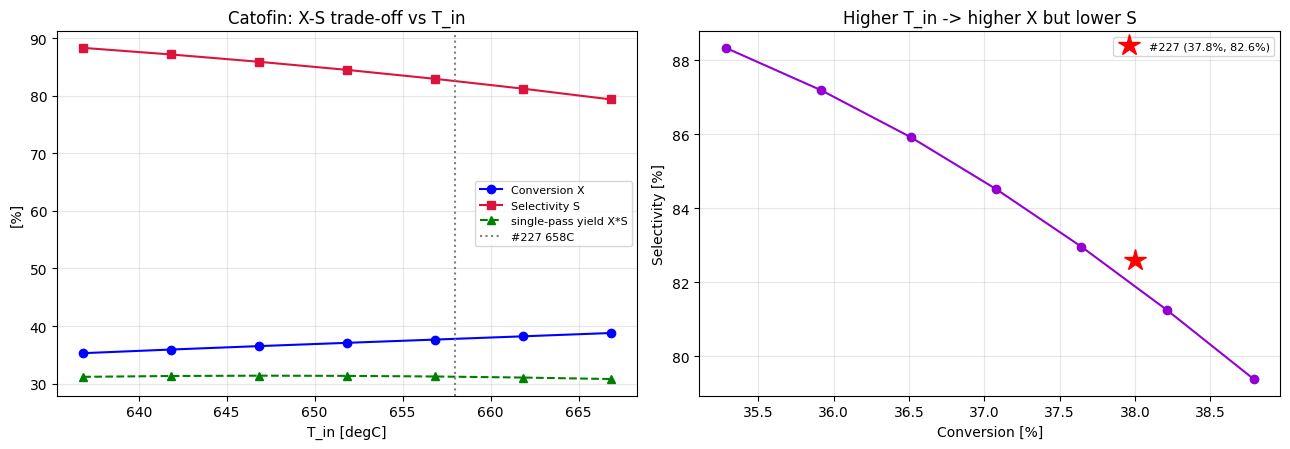

 T_in_C    X    S   XS  T_out
  636.8 35.3 88.3 31.2  586.8
  641.8 35.9 87.2 31.3  591.8
  646.8 36.5 85.9 31.4  596.8
  651.8 37.1 84.5 31.3  601.8
  656.8 37.6 83.0 31.2  606.8
  661.8 38.2 81.2 31.0  611.8
  666.8 38.8 79.4 30.8  616.8
→ 昇温で X↑/S↓ (Ea2>>Ea1)。範囲が狭い(930-940K)のは Dist2 の C2 必要量で T_in 下限が律速されるため
  (別ノート lpg/main の bounds)。S~82% は速度論で決まる経済最適。


In [4]:
rows = []
for Tc_in in np.arange(910, 945, 5.0):
    x = run_cat(T_in=Tc_in)
    if x['pen'] != 'OK':
        continue
    rows.append(dict(T_in_C=Tc_in-273.15, X=x['X'], S=x['S'], XS=x['X']*x['S']/100, T_out=x['Tout']))
sw = pd.DataFrame(rows)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].plot(sw.T_in_C, sw.X, 'o-', color='blue', label='Conversion X')
ax[0].plot(sw.T_in_C, sw.S, 's-', color='crimson', label='Selectivity S')
ax[0].plot(sw.T_in_C, sw.XS, '^--', color='green', label='single-pass yield X*S')
ax[0].axvline(T_IN-273.15, color='gray', ls=':', label=f'#227 {T_IN-273.15:.0f}C')
ax[0].set_xlabel('T_in [degC]'); ax[0].set_ylabel('[%]'); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[0].set_title('Catofin: X-S trade-off vs T_in')
ax[1].plot(sw.X, sw.S, 'o-', color='darkviolet')
ax[1].plot(38.0, 82.6, 'r*', ms=16, label='#227 (37.8%, 82.6%)')
ax[1].set_xlabel('Conversion [%]'); ax[1].set_ylabel('Selectivity [%]'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
ax[1].set_title('Higher T_in -> higher X but lower S')
plt.tight_layout(); plt.show()
print(sw.round(1).to_string(index=False))
print('→ 昇温で X↑/S↓ (Ea2>>Ea1)。範囲が狭い(930-940K)のは Dist2 の C2 必要量で T_in 下限が律速されるため')
print('  (別ノート lpg/main の bounds)。S~82% は速度論で決まる経済最適。')


## §4. Catofin 設計レバー — 転化率は何で決まるか

| レバー | 効果 (検証は下) |
|---|---|
| $L_{bed}$(浅床厚) | **転化率レバー**(床体積↑→X↑、HGM が温度を保つので平衡頭打ちなし)。S ほぼ不変 |
| $N_{online}$(並列基数) | **転化率+圧損レバー**(基数↑→流速↓→1基滞留時間↑→X↑、かつ ΔP↓) |
| $d_p$(粒径) | **純圧損レバー**(粒径↑→ΔP↓、X ほぼ不変) |


In [5]:
print('L_bed 掃引 (転化率レバー):')
for lb in (0.3, 0.5, 0.65, 0.8, 1.0):
    x = run_cat(L_bed=lb); print(f'  L_bed={lb:.2f}m: X={x["X"]:4.1f}%  S={x["S"]:4.1f}%  dP/P={x["dP"]:.1f}%  {x["pen"]}')
print('N_online 掃引 (転化率+圧損レバー):')
for n in (8, 10, 14, 18, 24):
    x = run_cat(N_online=n); print(f'  N_online={n:>2}: X={x["X"]:4.1f}%  S={x["S"]:4.1f}%  dP/P={x["dP"]:4.1f}%  {x["pen"]}')
print('d_p 掃引 (純圧損レバー, X 不変):')
for dp in (2, 3, 4, 6):
    x = run_cat(d_p=dp/1000.); print(f'  d_p={dp}mm: X={x["X"]:4.1f}%  dP/P={x["dP"]:4.1f}%  {x["pen"]}')
print('\n→ 転化率は L_bed と N_online (=床体積/滞留時間) で決まる。d_p は圧損のみ。')
print('  選択率はどのレバーでもほぼ一定 (速度論/温度で決まる)。')


L_bed 掃引 (転化率レバー):


  L_bed=0.30m: X=17.8%  S=82.0%  dP/P=2.5%  OK


  L_bed=0.50m: X=25.5%  S=82.8%  dP/P=2.8%  OK


  L_bed=0.65m: X=30.1%  S=82.8%  dP/P=3.0%  OK


  L_bed=0.80m: X=34.1%  S=82.8%  dP/P=3.3%  OK


...

  N_online=24: X=37.8%  S=82.6%  dP/P= 3.5%  OK
d_p 掃引 (純圧損レバー, X 不変):


  d_p=2mm: X=37.7%  dP/P= 7.3%  OK


  d_p=3mm: X=37.8%  dP/P= 3.7%  OK


  d_p=4mm: X=37.7%  dP/P= 3.0%  OK


  d_p=6mm: X=37.5%  dP/P= 2.5%  OK

→ 転化率は L_bed と N_online (=床体積/滞留時間) で決まる。d_p は圧損のみ。
  選択率はどのレバーでもほぼ一定 (速度論/温度で決まる)。


## §5. シミュレータ実走検証 (#227 再現 + 炭素収支)


In [6]:
x = run_cat()
print(f'(1) #227 再現: X={x["X"]:.1f}%  S={x["S"]:.1f}%  T_out={x["Tout"]:.0f}C  '
      f'(HGM floor {T_IN-273.15-DT_MAX:.0f}C)  N_total={x["Ntot"]}基  触媒={x["Wcat"]:.0f}t')
# 炭素収支
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    r = simulate_catofin_reactor_system(CatofinDesignVars(**CAT), feed)
Fo = r.effluent.F_out_avg
Cin  = 3*A0 + 3*B0
Cout = 3*Fo['A'] + 3*Fo['B'] + 2*Fo.get('D',0) + 1*Fo.get('E',0) + 2*Fo.get('F',0)
prop_made = Fo['B'] - B0; crack = Fo.get('E', 0.0)
print(f'(2) 炭素収支: C_in={Cin:.0f}  C_out={Cout:.0f}  closure={Cout/Cin*100:.2f}%')
print(f'    C3H6 正味生成={prop_made:.0f}  クラッキング(CH4)={crack:.0f} kmol/h  '
      f'→ 炭素ベース選択率={3*prop_made/(3*prop_made+3*crack)*100:.1f}% (損失=クラッキング)')
print(f'    T_out={r.effluent.T_out_avg-273.15:.0f}C ≈ HGM floor {T_IN-273.15-DT_MAX:.0f}C を確認')


(1) #227 再現: X=37.8%  S=82.6%  T_out=608C  (HGM floor 608C)  N_total=96基  触媒=1487t


(2) 炭素収支: C_in=16342  C_out=16342  closure=100.00%
    C3H6 正味生成=1189  クラッキング(CH4)=251 kmol/h  → 炭素ベース選択率=82.6% (損失=クラッキング)
    T_out=608C ≈ HGM floor 608C を確認


## §6. 結論

Catofin 反応器の単通転化率 ~38% と選択率 ~82% は、所与の熱力学・速度論 + HGM 等価熱補償から導かれる
挙動であり、シミュレータの不具合ではない。

1. **単通転化率(~38%)= HGM 補償 + 床体積で決まる**。純断熱なら強吸熱の自己冷却で平衡頭打ち(radial の問題)
   だが、Catofin の HGM が床温を $T_{in}-\Delta T_{max}$(=608°C)以上に維持するため、転化率は**床体積
   ($L_{bed},N_{online}$)でスケール**する(§2,§4)。代償は HGM 補償熱(燃料)+触媒・反応器数。
2. **選択率(~82%)= 速度比 + 失活で決まる経済最適**(物理上限でない)。降温/短サイクルで↑可だが
   生産量↓・反応器数↑ の代償。BO はそれらと釣り合う ~82% を選んだ。
3. **radial 時代との違い**: radial 断熱床は「平衡頭打ち・体積無効」。Catofin は HGM で「体積で転化率が伸びる」。
   律速は平衡でなく「HGM がどれだけ床温を保てるか($\Delta T_{max}$)」と「選択率トレードオフ」。

> HGM 補償は等価モデル(`PDH_CATOFIN_DTMAX` で床温降下上限を表現)。再生動特性の詳細は未計上=スコープ外。
> 数値は #227 設計点。$\Delta T_{max}$ 感度は env で確認可。
